<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab02/lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 02**

**Zadanie 1**

Celem zadania jest przygotowanie sieci neuronowej do badania działania leku na podstawie stężenia składników w próbce krwi. Wyniki badań zostały pobrane z pliku *medicine.txt*.

In [2]:
#Wymagane importy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.datasets import load_digits
import time
import random
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

Wczytanie danych z pliku

In [4]:
data = pd.read_csv('./medicine.txt', delimiter=",")

Wczytanie danych do zmiennych X oraz y

In [5]:
X = data.iloc[:,:-1]
y = data.iloc[:, -1]

W celu uzsykania jak najdokładniejszej analizy, przeprowadzono wyszukiwanie oraz ewentualne usunięcie oulinerów z danych dostarczonych przez plik *medicine.txt*

In [7]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((X < lower_bound) | (X > upper_bound)).any(axis=1)
X = X[mask]
y = y[mask]

print(f"Usunięto {data.shape[0] - X.shape[0]} wartości odstających")

Usunięto 86 wartości odstających


Rozbicie danych na trenujące i testujące, przyjęto rozkład 80% / 20%

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = y, random_state=0)

Następnie przeprowadzono normalizacię danych z użyciem metody MinMaxScaler() z bilioteki skikit

In [9]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Zedfiniowano funkcję do rysowania granicy decyzyjnej w celu ograniczenia ilości kodu

In [10]:
def plot_decision_boundary(model, X, y, grid_size=100, x_range=(-1.5, 1.5), y_range=(-1.5, 1.5)):
    xx, yy = np.meshgrid(
        np.linspace(x_range[0], x_range[1], grid_size),
        np.linspace(y_range[0], y_range[1], grid_size)
    )

    test_points = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(test_points).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, predictions, alpha=0.6, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=100, cmap='coolwarm')
    plt.title("Granica decyzyjna dla MLP")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

Zdefiniowano funkcję do wypisywania danych do analizy, na podstawie modelu, oraz danych testowych. Będzie ona używana w każdym kolejnym zadaniu

In [11]:
def evaluate_classification(model, X_test, y_test):
    predicted_labels_test = model.predict(X_test)
    accuracy = accuracy_score(y_test, predicted_labels_test)
    precision = precision_score(y_test, predicted_labels_test, average='weighted')
    recall = recall_score(y_test, predicted_labels_test, average='weighted')
    f1 = f1_score(y_test, predicted_labels_test, average='weighted')

    print(f"Dokładność: {accuracy:.4f}")
    print(f"Precyzja: {precision:.4f}")
    print(f"Czułość: {recall:.4f}")
    print(f"Miara F1: {f1:.4f}")

    print("\nRaport klasyfikacji:\n", classification_report(y_test, predicted_labels_test))

Przeprowadzono 7 prób, dla różnych architektur sieci neuronowej. Dla każdej z nich wyznaczono:
* Score na zbiorze treningowym
* Score na zbiorze testowym
* Czas trwania nauki - dla dużej ilości danych ma on znaczenie, a zmiana architektury ma ogromny wpływ na czas trwania
* Dokładność modelu
* Precyzję modelu
* Czułość modelu
* Miarę F1
* Wygenerowano raport kwalifikacji
* Wygenerowano wykres z użyciem metody plot_decision_boundary

1. Próba dla 2 warstw, każda po 5 neuronów.

Score na zbiorze treningowym: 0.8942
Score na zbiorze testowym: 0.9289
Czas wykonania model.fit(): 1.1590 sekundy
Dokładność: 0.9289
Precyzja: 0.9291
Czułość: 0.9289
Miara F1: 0.9289

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94       145
           1       0.91      0.93      0.92       108

    accuracy                           0.93       253
   macro avg       0.93      0.93      0.93       253
weighted avg       0.93      0.93      0.93       253



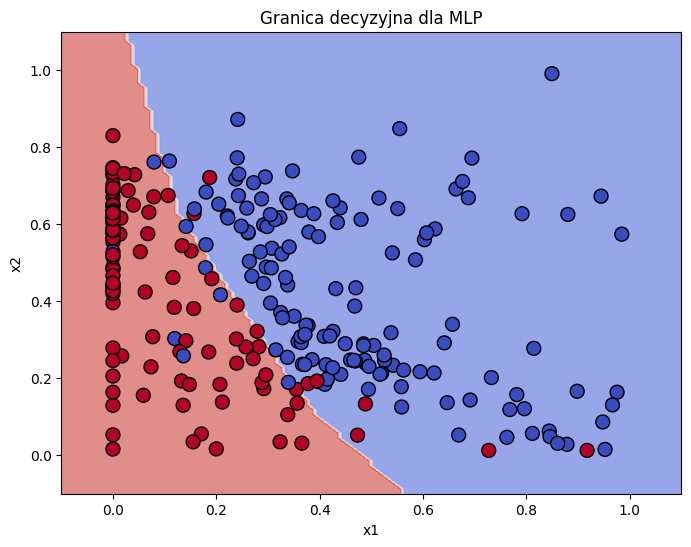

In [13]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

Na podstawie wyników analizy, można zauważyć, że model wykazał większy score dla danych testowych, niż treningowych, co wskazuje na to że nie został on przeuczony, a jednocześnie zachowuje bardzo dobre wyniki, powyżej 0.9.

Metryki klasyfikacji dla danych testowych są wysokie, wszystkie powyżej 0.92, oznacza to, że sieć dobrze identyfikuje obie klasy.

Czas trwania badania to trochę ponad sekunda, co jest dobrym wynikiem, jak na osiągnięte rezultaty.

2. Próba dla 5 warstw po 3 neurony

Score na zbiorze treningowym: 0.9169
Score na zbiorze testowym: 0.9249
Czas wykonania model.fit(): 4.5016 sekundy
Dokładność: 0.9249
Precyzja: 0.9268
Czułość: 0.9249
Miara F1: 0.9252

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93       145
           1       0.89      0.94      0.91       108

    accuracy                           0.92       253
   macro avg       0.92      0.93      0.92       253
weighted avg       0.93      0.92      0.93       253



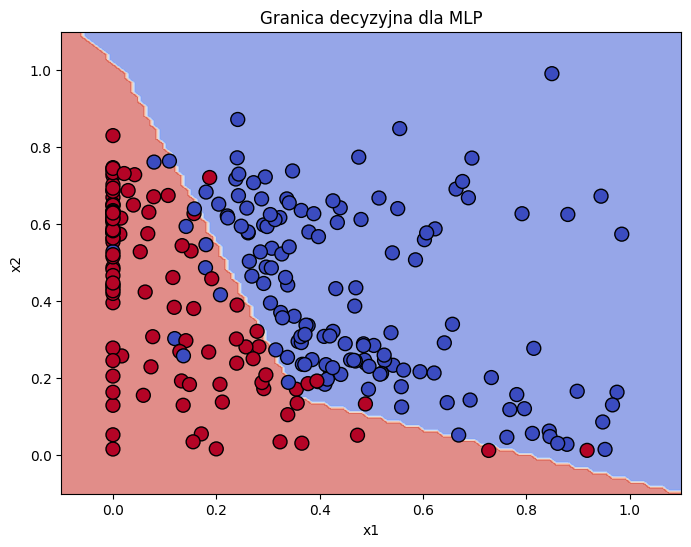

In [14]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (3,3,3,3,3), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

Czas trwania badania dla tego modelu wyniósł 4.5 sekundy. Wydaje się to dalej mało, lecz z drugiej strony patrząc, jest to około 3.5 razy więcej niż w badaniu 1. Przy bardzo dużej liczbie dancyh, takie wartości mogą okazać się znaczące, zwłasza jeżeli zostaną porównane wyniki analizy, zauważamy że skuteczność jak i miara F1 są prawie identyczne. Ciekawe wydaje się zachowanie na wykresie, możemy zauważyć że model w tej architektruze zauważył czerwony punkt ( na osi OX około 0.72, OY: 0.05 ) i próbował sięgnąć po niego.

3. Próba dla dwócch wartstw po 25 neuronów

Score na zbiorze treningowym: 0.9110
Score na zbiorze testowym: 0.9328
Czas wykonania model.fit(): 2.5354 sekundy
Dokładność: 0.9328
Precyzja: 0.9347
Czułość: 0.9328
Miara F1: 0.9330

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       145
           1       0.90      0.95      0.92       108

    accuracy                           0.93       253
   macro avg       0.93      0.94      0.93       253
weighted avg       0.93      0.93      0.93       253



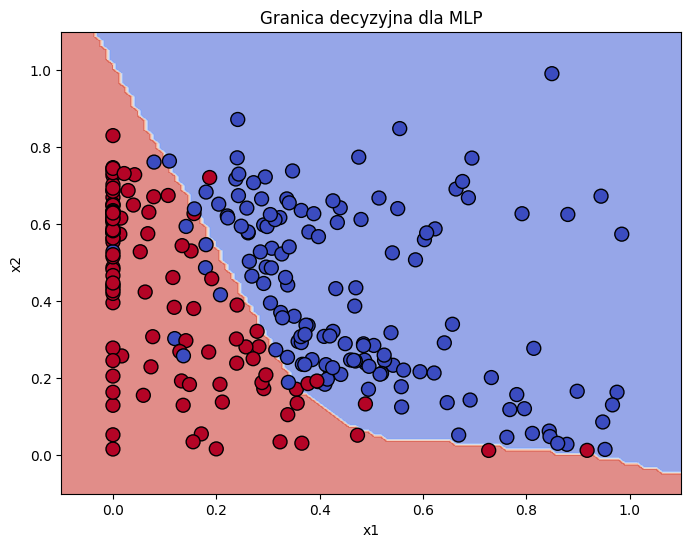

In [15]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (25,25), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

Próba przerwowadzona na dwuwarstwowej architektrze, lecz o dużo większej liczbie neutronów niż w próbie 1, przyniosła lepsze rezultaty niż w próbie 2 z większą ilością warstw i mniejszą liczbą neutronów. Oczywiście wyniki są do siebie bardzo zbliżone, może to być wręcz kwestia losowości, lecz mimo to warto zauważyć różnicę, że czas badania jest mniejszy, a efektywność większa.

4. Próba dla dwóch wartstw po 100 neuronów

Score na zbiorze treningowym: 0.9199
Score na zbiorze testowym: 0.9289
Czas wykonania model.fit(): 4.2197 sekundy
Dokładność: 0.9289
Precyzja: 0.9312
Czułość: 0.9289
Miara F1: 0.9291

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.91      0.94       145
           1       0.89      0.95      0.92       108

    accuracy                           0.93       253
   macro avg       0.93      0.93      0.93       253
weighted avg       0.93      0.93      0.93       253



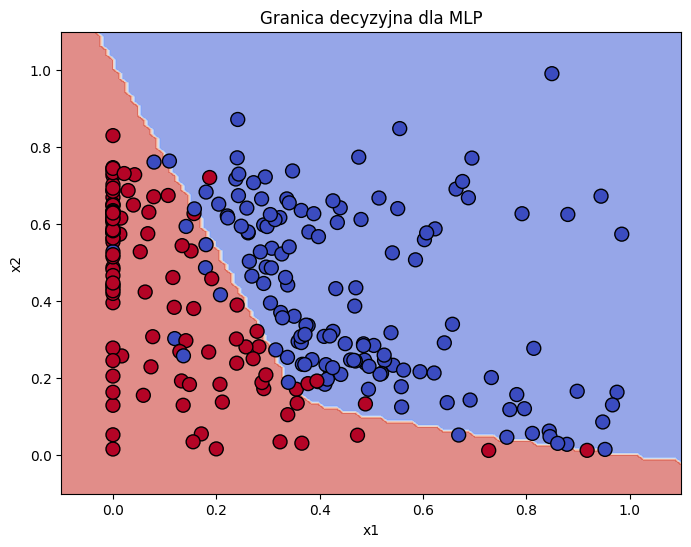

In [16]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (100,100), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

Po analizie próby nr. 3, gdzie dwuwarstwowa architektura z ilością netronów 25 wykazała dotychczasz najlepsze rezultaty, postanowiono zwiększyść ilośćneutronów 4-krotnie, nie zmieniając ilości warstw. Zauważono że nie przyniosło to efektów, wyniki efetywności oraz F1 są prawie identyczne, natomiast zwiększył się czas badania.

5. Próba dla 2 warstw po 1000 nauronów

Score na zbiorze treningowym: 0.9041
Score na zbiorze testowym: 0.9328
Czas wykonania model.fit(): 52.4232 sekundy
Dokładność: 0.9328
Precyzja: 0.9328
Czułość: 0.9328
Miara F1: 0.9328

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       145
           1       0.93      0.92      0.92       108

    accuracy                           0.93       253
   macro avg       0.93      0.93      0.93       253
weighted avg       0.93      0.93      0.93       253



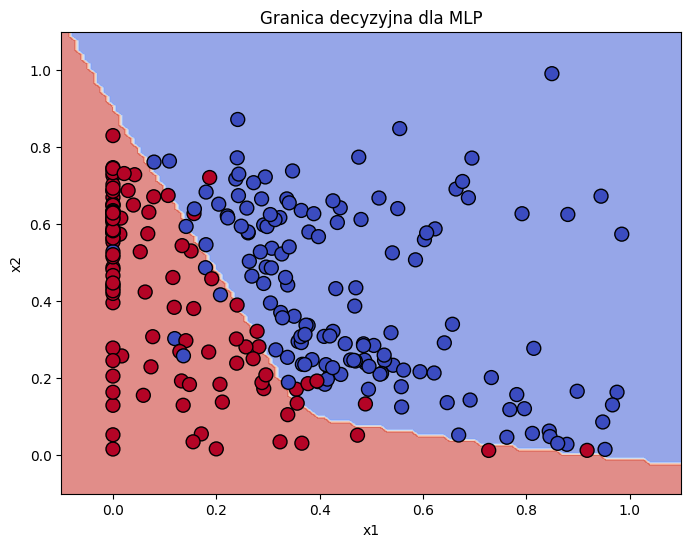

In [17]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (1000,1000), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

W celu sprawdzenia, czy ogromna ilość neutronów da jakikolwiek efekt, przeprowadzono badanie na architekturze (1000, 1000). Ta próba upewniła wniosek, że dokładanie więszkej ilości neutronów, nie zawsze ma odzwierciedlenie w wynikach badania. Czas poświęcony na naukę to aż 40 sekund, a efektywność oraz F1, dalej bez zmian.

6. Próba dla 3 warstw po 100 neuronów

Score na zbiorze treningowym: 0.9159
Score na zbiorze testowym: 0.9249
Czas wykonania model.fit(): 5.5964 sekundy
Dokładność: 0.9249
Precyzja: 0.9268
Czułość: 0.9249
Miara F1: 0.9252

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93       145
           1       0.89      0.94      0.91       108

    accuracy                           0.92       253
   macro avg       0.92      0.93      0.92       253
weighted avg       0.93      0.92      0.93       253



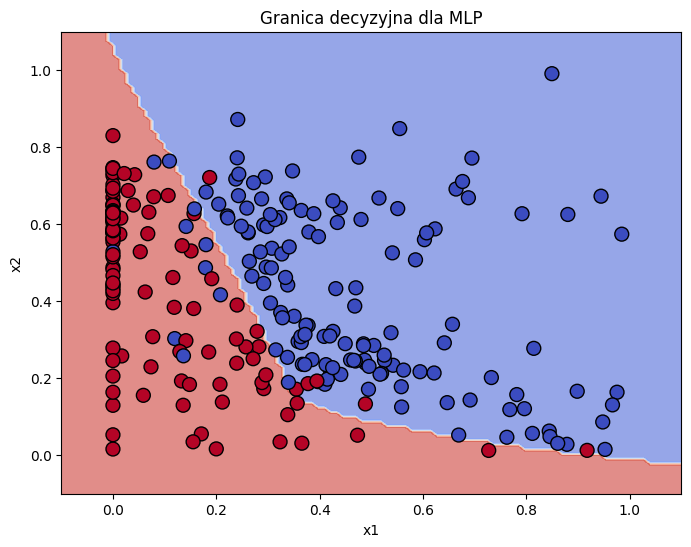

In [18]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (100,100,100), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

Próba została przeprowadzona, wykorzystując dużą liczbę netronów, lecz dodając dodatkową warstwę. Zauważono że poza zwiększeniem czasu nauki, wyniki nie uległy zmianie

7. Próba dla 10 warstw po 2 neurony

Score na zbiorze treningowym: 0.5717
Score na zbiorze testowym: 0.5731
Czas wykonania model.fit(): 0.6647 sekundy
Dokładność: 0.5731
Precyzja: 0.3285
Czułość: 0.5731
Miara F1: 0.4176

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.57      1.00      0.73       145
           1       0.00      0.00      0.00       108

    accuracy                           0.57       253
   macro avg       0.29      0.50      0.36       253
weighted avg       0.33      0.57      0.42       253



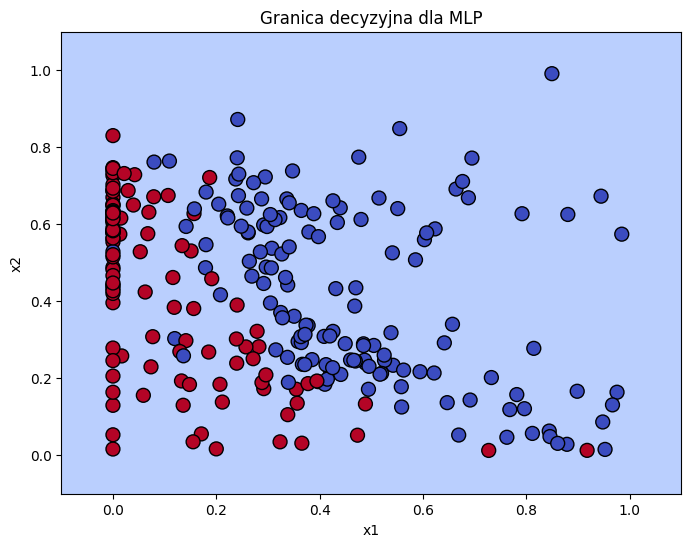

In [20]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (2,2,2,2,2,2,2,2), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)
plot_decision_boundary(model, X_test, y_test, x_range=(-0.1, 1.1), y_range=(-0.1, 1.1))

Ostatnia próba miała sprawdzić, co się wydarzy w przypadku dużej ilości warstw i małej liczbie neutronów. Zauważono, że czas badania był minimalny (0.67 sekundy), lecz rezultaty tragiczne. Sieć zakwalifikowała wszystkie dane do klasy 1, stąd efektywność 0.57. Próba nr. 7 pokazała, że niepotrzebne zwiększanie ilości warstw, może przeszkadzać w nauczaniu sieci.

**Zadanie 2**

Na podstawie zbioru ręcznie pisanych cyfr z https://www.google.com/url?q=https%3A%2F%2Farchive.ics.uci.edu%2Fml%2Fdatasets%2FOptical%2BRecognition%2Bof%2BHandwritten%2BDigits przebadano skuteczność klasyfikacji na zbiorze, za pomocą wielowarstwowych sieci neuronowych.

Pobranie danych

In [21]:
digits = load_digits()
X, y = digits.data, digits.target

Dane nie zawierają outlinerów, więc pominięto ich usuwanie.

Podział danych

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

Skalowanie danych

In [23]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

W celu analizy wykorzystano metody, oraz sposoby z zadania 1. Pominięto generowanie wykresu.

1. Test dla 2 warstw po 5 neuronów

In [25]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9311
Score na zbiorze testowym: 0.8861
Czas wykonania model.fit(): 5.2957 sekundy
Dokładność: 0.8861
Precyzja: 0.8883
Czułość: 0.8861
Miara F1: 0.8848

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.80      0.92      0.86        36
           2       0.86      0.89      0.87        35
           3       0.81      0.95      0.88        37
           4       0.97      0.92      0.94        36
           5       0.94      0.92      0.93        37
           6       0.94      0.89      0.91        36
           7       0.92      0.97      0.95        36
           8       0.85      0.66      0.74        35
           9       0.80      0.78      0.79        36

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.88       360
weighted avg       0.89      0.89      0.88       360



Podobnie jak w zadaniu 1, próba 1, rezultaty dla architektury (5,5) są zadowalające.

2. Test dla 3 warstw po 5 neutronów

In [27]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (5,5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9729
Score na zbiorze testowym: 0.9139
Czas wykonania model.fit(): 8.6320 sekundy
Dokładność: 0.9139
Precyzja: 0.9158
Czułość: 0.9139
Miara F1: 0.9127

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.80      0.92      0.86        36
           2       0.97      0.91      0.94        35
           3       0.92      0.97      0.95        37
           4       0.91      0.89      0.90        36
           5       0.95      0.97      0.96        37
           6       0.92      0.94      0.93        36
           7       0.88      1.00      0.94        36
           8       0.83      0.69      0.75        35
           9       1.00      0.86      0.93        36

    accuracy                           0.91       360
   macro avg       0.92      0.91      0.91       360
weighted avg       0.92      0.91      0.91       360



W tej próbie, w porównaniu do 1, dodano dodatkową warstwę, wyniki poprawiły się o około 0.3 dla efektywności oraz miary F1, przy niewielkim zwiększeniu czasu badania. W porównaniu do zadania 1, i prób 4 oraz 6, gdzie dodanie warstwy nie poprawiło rezultatów, zauważono, że w tym przypadku dodanie warstwy pomogło. To pokazuje jak dobranie architektury, jest znaczące dla posiadanych danych próbkowych.

3. Test dla 4 warstw po 5 neutronów

In [28]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (5,5,5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9770
Score na zbiorze testowym: 0.8833
Czas wykonania model.fit(): 7.0370 sekundy
Dokładność: 0.8833
Precyzja: 0.8859
Czułość: 0.8833
Miara F1: 0.8835

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        36
           1       0.81      0.81      0.81        36
           2       0.97      0.91      0.94        35
           3       0.85      0.89      0.87        37
           4       0.97      0.89      0.93        36
           5       0.92      0.95      0.93        37
           6       0.83      0.94      0.88        36
           7       0.95      0.97      0.96        36
           8       0.78      0.71      0.75        35
           9       0.79      0.83      0.81        36

    accuracy                           0.88       360
   macro avg       0.89      0.88      0.88       360
weighted avg       0.89      0.88      0.88       360



W tej próbie dodano kolejną warstwę do architektury modelu. Zauważono, że wyniki się nie zmieniły ( score na zbiorze treningowym ), a wręcz pogorszyły ( spadek F1 o 0.3 ). Ciekawych zachowaniem jest zmniejszenie czasu nauki przy zwiększeniu ilości warstw.

4. Test dla 5 warstw po 5 neutronów

In [29]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (5,5,5,5,5), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9562
Score na zbiorze testowym: 0.8500
Czas wykonania model.fit(): 8.0831 sekundy
Dokładność: 0.8500
Precyzja: 0.8535
Czułość: 0.8500
Miara F1: 0.8499

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89        36
           1       0.64      0.69      0.67        36
           2       0.97      0.94      0.96        35
           3       0.95      1.00      0.97        37
           4       0.91      0.81      0.85        36
           5       0.89      0.84      0.86        37
           6       0.94      0.94      0.94        36
           7       0.92      0.97      0.95        36
           8       0.65      0.74      0.69        35
           9       0.79      0.64      0.71        36

    accuracy                           0.85       360
   macro avg       0.85      0.85      0.85       360
weighted avg       0.85      0.85      0.85       360



W próbie nr. 4 dodano jeszcze jedną warstwę, wyniki ponownie się pogorszyły, przy tym samym czasie badania. Potwierdzia to regułę, że dodawanie zbyt dużej ilości warstw, powoduje problemy.

5. Test dla 2 warstw po 100 neuronów

In [30]:
start_time = time.time()
model = MLPClassifier(hidden_layer_sizes = (100, 100), max_iter=2000)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f'Score na zbiorze treningowym: {train_score:.4f}')
print(f'Score na zbiorze testowym: {test_score:.4f}')
print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 1.0000
Score na zbiorze testowym: 0.9694
Czas wykonania model.fit(): 8.2998 sekundy
Dokładność: 0.9694
Precyzja: 0.9705
Czułość: 0.9694
Miara F1: 0.9696

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.95      1.00      0.97        37
           4       1.00      0.97      0.99        36
           5       0.95      0.97      0.96        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.94      0.91      0.93        35
           9       0.97      0.94      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



Ostatnia próba powróciła do architektury z dwoma warstami, lecz w porównaniu do próby nr. 1, zwiększono ilość neutronów 20 - krotnie. Wyniki okazały się najlepsze w porównaniu do wszystkich poprzednich prób. Duża ilość neutronów doprowadziła do efektywności 1.0 na zbiorze treningowych, oraz 0.97 na testowym. Wynik miary F1 na poziomie 0.97 również jest bardzo dobrym rezultatem, przy niewielkiej zmianie czasu liczenia. Można wnioskować, że duża ilość neutronów pomaga w dokładności analizy.

**Zadanie 3**

Celem zadania 3, będzie przeprowadzenie analizy dla danych z zadania 2, z wykorzystaniem różnych architektur sieci, funkcji aktywacji, ilości epok uczenia, algorytmów uczenia, współczynnika uczenia. W pierwszej kolejności badano różne parametry, dla pozostałych paramtrów domyślnych, a następnie losowano parametry z puli. Dodatkowo podczas badania współczynnika uczenia skupiono się na algorytmie SGD

Zdefiniowano funkcję aktywacji.

In [32]:
f_aktywacji = np.array(['identity','logistic', 'tanh', 'relu'])

W zadaniu 2 najlepsze wyniki osiągnięto dla architektury (100,100), dlatego zostanie ona użyta do analizy różnych funkcji aktywacji.

In [33]:
for f in f_aktywacji:
    start_time = time.time()

    model = MLPClassifier(hidden_layer_sizes = (100, 100), max_iter=2000, activation=f)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f'Score na zbiorze treningowym: {train_score:.4f}')
    print(f'Score na zbiorze testowym: {test_score:.4f}')
    print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
    evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 1.0000
Score na zbiorze testowym: 0.9639
Czas wykonania model.fit(): 4.4150 sekundy
Dokładność: 0.9639
Precyzja: 0.9650
Czułość: 0.9639
Miara F1: 0.9640

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.87      0.94      0.91        36
           2       1.00      0.97      0.99        35
           3       0.95      1.00      0.97        37
           4       1.00      0.94      0.97        36
           5       0.95      0.97      0.96        37
           6       0.97      0.97      0.97        36
           7       1.00      1.00      1.00        36
           8       0.94      0.89      0.91        35
           9       0.97      0.94      0.96        36

    accuracy                           0.96       360
   macro avg       0.97      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360

Score na zbiorze treningowym: 1.000

Efektywność na danych treningowych przy każdej z użytych funkcji wyniosła 1.0, lecz najlepsza efektwyność została osiągnięta dla funkcjii *relu*. Mimo to, rezultaty są do siebie bardzo zbliżone, wręcz pomijalne, więc można wyciągnąć wnioski, że w tym przypadku, dobór funkcji nie ma większego znaczenia. Najwięszke różnice dotyczą czasu szkolenia, najmniejsza została osiągnięta dla funkcji *relu*, a najwięszka dla *logistic*.

Testy dla różnych ilości epok:

In [37]:
il_epok = np.array([10, 50, 100, 500])

W zadaniu 2 najlepsze wyniki osiągnięto dla architektury (100,100), dlatego zostanie ona użyta do analizy różnych ilości epok.

In [38]:
for il in il_epok:
    start_time = time.time()

    model = MLPClassifier(hidden_layer_sizes = (100, 100), max_iter=il)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f'Score na zbiorze treningowym: {train_score:.4f}')
    print(f'Score na zbiorze testowym: {test_score:.4f}')
    print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
    evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.9402
Score na zbiorze testowym: 0.9389
Czas wykonania model.fit(): 0.2233 sekundy
Dokładność: 0.9389
Precyzja: 0.9418
Czułość: 0.9389
Miara F1: 0.9394

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.80      0.92      0.86        36
           2       1.00      0.97      0.99        35
           3       1.00      0.95      0.97        37
           4       1.00      0.94      0.97        36
           5       0.92      0.95      0.93        37
           6       1.00      0.94      0.97        36
           7       0.95      1.00      0.97        36
           8       0.88      0.80      0.84        35
           9       0.87      0.92      0.89        36

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360

Score na zbiorze treningowym: 0.996

Badanie ilości epok pokazało, że już 10 epok wystarczy, aby uzyskać efektywność oraz miarę F1 na poziomie około 0.94. Efektywność na poziomie 1.0, osiągnięto już przy 100 epokach.

Testy dla różnych architektur sieci dokładnie zostały przeanalizowane w zadaniu 2, dlatego poniższa tablica posłuży do losowania architektury podczas badania mieszania algorytmów, funkcji i learning rate

In [ ]:
arch_sieci = [(5, 5), (25, 25, 25), (4, 4, 4, 100), (123, 76, 5, 88), (4, 4, 4, 4, 4)]

Testy dla różnych algorytmów uczenia

In [ ]:
alg_uczenia = ['adam', 'sgd', 'lbfgs']

W zadaniu 2 najlepsze wyniki osiągnięto dla architektury (100,100), dlatego zostanie ona użyta do analizy różnych algorytmów uczenia.

In [ ]:
for alg in alg_uczenia:
    start_time = time.time()

    model = MLPClassifier(hidden_layer_sizes = (100, 100), max_iter=2000, solver=alg)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f'Score na zbiorze treningowym: {train_score:.4f}')
    print(f'Score na zbiorze testowym: {test_score:.4f}')
    print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
    evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 1.0000
Score na zbiorze testowym: 0.9750
Dokładność: 0.9750
Precyzja: 0.9758
Czułość: 0.9750
Miara F1: 0.9751

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       1.00      0.97      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.94      0.91      0.93        35
           9       0.97      0.94      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.98       360

Score na zbiorze treningowym: 0.9923
Score na zbiorze testowym: 0.9694
Dokładn

Testy dla różnych rozmiarów learning rate

In [ ]:
learning_rates = [5, 1, 0.1, 0.01, 0.001, 0.000001]

Warto dodać że znajduje się tutaj również współczynnik uczenia o wartości 5. Dla poniższego przykładu (tzn. z pozostałymi parametrami domyślnymi) działa, mimo że jego accuracy stanowi około 0.97. Niestety podczas próby mieszania parametrów modelu, zdarzały się sytuacje w których taki współczynnik powodował błąd kompilacji, wartość współczynnika była określana jako NaN bądź infinity, dltego został usunięty z tablicy.

In [ ]:
for r in learning_rates:
    start_time = time.time()

    model = MLPClassifier(hidden_layer_sizes = (100, 100), max_iter=2000, learning_rate_init=r)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f'Score na zbiorze treningowym: {train_score:.4f}')
    print(f'Score na zbiorze testowym: {test_score:.4f}')
    print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
    evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.0967
Score na zbiorze testowym: 0.0972
Czas wykonania model.fit(): 2.6738 sekundy
Dokładność: 0.0972
Precyzja: 0.0095
Czułość: 0.0972
Miara F1: 0.0172

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.00      0.00      0.00        36
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        37
           4       0.00      0.00      0.00        36
           5       0.00      0.00      0.00        37
           6       0.00      0.00      0.00        36
           7       0.00      0.00      0.00        36
           8       0.10      1.00      0.18        35
           9       0.00      0.00      0.00        36

    accuracy                           0.10       360
   macro avg       0.01      0.10      0.02       360
weighted avg       0.01      0.10      0.02       360

Score na zbiorze treningowym: 0.101

In [ ]:
learning_rates = [ 1, 0.1, 0.01, 0.001, 0.000001]

Jako że analiza dotyczy 4 funkcji aktywacji, 4 ilości epok, 5 architektur, 3 algorytmów uczenia, oraz 5 wartości learning rate, a ich permutacja to 1200, to postanowiłem wylosować 30 różnych kombinacji, prosto je opisać, a najciekawsze dokładniej przeanalizować. Poniżej kod, oraz rezultaty:

In [ ]:
model_results = []

for _ in range(30):
  activation_function = random.choice(f_aktywacji)
  epochs = random.choice(il_epok)
  architecture = random.choice(arch_sieci)
  solver = random.choice(alg_uczenia)
  learning_rate = random.choice(learning_rates)

  print(f"Wylosowane wartości:")
  print(f"Funkcja aktywacji: {activation_function}")
  print(f"Liczba epok: {epochs}")
  print(f"Architektura sieci: {architecture}")
  print(f"Algorytm uczenia: {solver}")
  print(f"Współczynnik uczenia: {learning_rate} \n\n\n")

  start_time = time.time()

  model = MLPClassifier(hidden_layer_sizes=architecture, activation=activation_function, solver=solver, max_iter=epochs, learning_rate_init=learning_rate, random_state=42)
  model.fit(X_train, y_train)

  print(f'Score na zbiorze treningowym: {model.score(X_train, y_train):.4f}')
  print(f'Score na zbiorze testowym: {model.score(X_test, y_test):.4f}')
  print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
  model_results.append({"model": model, "activation_function": activation_function, "epochs": epochs, "architecture": architecture, "solver": solver, "learning_rate": learning_rate, "training_time": (time.time() - start_time)})

evaluate_classification(model_results[2]['model'], X_test, y_test)


Wylosowane wartości:
Funkcja aktywacji: identity
Liczba epok: 2000
Architektura sieci: (4, 4, 4, 4, 4)
Algorytm uczenia: sgd
Współczynnik uczenia: 0.001
Score na zbiorze treningowym: 0.6096
Score na zbiorze testowym: 0.6167
Czas wykonania model.fit(): 2.6417 sekundy
Wylosowane wartości:
Funkcja aktywacji: logistic
Liczba epok: 500
Architektura sieci: (5, 5)
Algorytm uczenia: adam
Współczynnik uczenia: 0.001
Score na zbiorze treningowym: 0.3299
Score na zbiorze testowym: 0.3583
Czas wykonania model.fit(): 1.1486 sekundy
Wylosowane wartości:
Funkcja aktywacji: relu
Liczba epok: 500
Architektura sieci: (4, 4, 4, 4, 4)
Algorytm uczenia: sgd
Współczynnik uczenia: 1e-06
Score na zbiorze treningowym: 0.1009
Score na zbiorze testowym: 0.1028
Czas wykonania model.fit(): 0.1314 sekundy
Wylosowane wartości:
Funkcja aktywacji: logistic
Liczba epok: 500
Architektura sieci: (4, 4, 4, 100)
Algorytm uczenia: adam
Współczynnik uczenia: 1e-06
Score na zbiorze treningowym: 0.1016
Score na zbiorze testowy

ValueError: Solver produced non-finite parameter weights. The input data may contain large values and need to be preprocessed.

**Zadanie 5**
Proszę pobrać zbiór yeast z UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Yeast). Proszę we własnym zakresie dokonać wstępnej analizy i przygotowania tego zbioru. Warto zauważyć, że liczności różnych klas wewnątrz zbioru są bardzo nierówne. Proszę spróbować osiągnąć jak najlepsze wyniki i narysować dla nich macierz pomyłek (dla zbioru uczącego i testującego) oraz wyliczyć wszystkie poznane do tej pory metryki. Czy dokładność na poziomie 0.5 dla takiego zbioru jest dobra? Mogą państwo zbadać też czas wykonywania funkcji fit dla różnych konfiguracji sieci.

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

yeast = fetch_ucirepo(id=110)

Sprawdzamy liczebność klas i od razu zauważamy ogromną dysproporcję. Klasa ERL występuje 5 razy, a klasa CYT aż 463 razy, co na pewno utrudni analizę oraz poprawną naukę sieci.

In [ ]:
X = yeast.data.features
y = yeast.data.targets
print(y.value_counts())

localization_site
CYT                  463
NUC                  429
MIT                  244
ME3                  163
ME2                   51
ME1                   44
EXC                   35
VAC                   30
POX                   20
ERL                    5
Name: count, dtype: int64


Teraz należy nadać klasą wartości liczbowe. Konwencja:
*   CYT                    0
*   NUC                    1
*   MIT                    2
*   ME3                    3
*   ME2                    4
*ME1                    5
*EXC                    6
*VAC                    7
*POX                    8
*ERL                    9

In [ ]:
class_mapping = {'CYT': 0, 'NUC': 1, 'MIT': 2, 'ME3': 3, 'ME2': 4, 'ME1': 5, 'EXC': 6, 'VAC': 7, 'POX': 8, 'ERL': 9}

y = y['localization_site'].map(class_mapping)

W ramach tego zadania zakładamy dość standardowy podział zbioru treningowego i testowego 80% / 20%

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

Sprawdzamy czy dane zawierają się w pewnej skali. Obserwując zachowanie pierwszych 10, dochodzimy do wniosku że skala jest porównywalna

In [ ]:
print(X.head(10))

    mcg   gvh   alm   mit  erl  pox   vac   nuc
0  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22
1  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22
2  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22
3  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22
4  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22
5  0.51  0.40  0.56  0.17  0.5  0.5  0.49  0.22
6  0.50  0.54  0.48  0.65  0.5  0.0  0.53  0.22
7  0.48  0.45  0.59  0.20  0.5  0.0  0.58  0.34
8  0.55  0.50  0.66  0.36  0.5  0.0  0.49  0.22
9  0.40  0.39  0.60  0.15  0.5  0.0  0.58  0.30


Zważając na najprawdopodobniej poprawną skalę oraz brak outlinerów, ograniczyłem się do przeiterowania po wartościach i sprawdzenia czy napewno wszystkie są z zakresu 0.0 <-> 1.0

In [ ]:
is_within_range = np.all((X >= 0) & (X <= 1))
print("Czy wszystkie wartości w X są w przedziale [0, 1]? ", is_within_range)

Czy wszystkie wartości w X są w przedziale [0, 1]?  True


Skala, oraz outlinery potwierdzone i sprawdzone, więc dochodzimy do wniosku, że jedynym problemem będą różne zbiory wartości dla różnych klas. Przetestuję dane dla kilku architektur i postaram się wyciągnąć wnioski

In [ ]:
arch_ex_5 = [(5,5), (100,100), (4,4,4,4), (25,25,25)]
for arch in arch_ex_5:
  start_time = time.time()

  model = MLPClassifier(hidden_layer_sizes = arch, max_iter=2000)
  model.fit(X_train, y_train)

  print(f'Score na zbiorze treningowym: {model.score(X_train, y_train):.4f}')
  print(f'Score na zbiorze testowym: {model.score(X_test, y_test):.4f}')
  print(f"Czas wykonania model.fit(): {(time.time() - start_time):.4f} sekundy")
  evaluate_classification(model, X_test, y_test)

Score na zbiorze treningowym: 0.5855
Score na zbiorze testowym: 0.5724
Czas wykonania model.fit(): 6.2560 sekundy
Dokładność: 0.5724
Precyzja: 0.5692
Czułość: 0.5724
Miara F1: 0.5597

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.50      0.71      0.59        93
           1       0.56      0.41      0.47        86
           2       0.65      0.57      0.61        49
           3       0.85      0.91      0.88        32
           4       0.27      0.30      0.29        10
           5       0.56      0.56      0.56         9
           6       0.50      0.29      0.36         7
           7       0.00      0.00      0.00         6
           8       1.00      0.50      0.67         4
           9       0.00      0.00      0.00         1

    accuracy                           0.57       297
   macro avg       0.49      0.42      0.44       297
weighted avg       0.57      0.57      0.56       297

Score na zbiorze treningowym: 0.653

TODO -> zrobić sprawozdanie, ale to dopiero po tym, jak będzie ocena z poprzednieg